In [30]:
!pip install xgboost tensorflow keras

In [31]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# 1. CONFIGURATION & CONSTANTS

In [32]:
RAW_PATH = "traffic_accidents.csv"
TARGET = "crash_type"

In [33]:
BASELINE_RESULTS_PATH = "baseline_results.json"
DEEP_RESULTS_PATH = "deep_model_results.json"
HISTORY_PATH = "deep_model_history.json"
SEARCH_LOG_PATH = "architecture_search_log.json"

In [34]:
LEAKAGE_COLS = [
    "most_severe_injury", "injuries_total", "injuries_fatal",
    "injuries_incapacitating", "injuries_non_incapacitating",
    "injuries_reported_not_evident", "injuries_no_indication",
]

In [35]:
CATEGORICAL_COLS = [
    "traffic_control_device", "weather_condition", "lighting_condition",
    "first_crash_type", "trafficway_type", "alignment", "roadway_surface_cond",
    "road_defect", "intersection_related_i", "damage", "prim_contributory_cause",
    "day_period", "season", "is_weekend",
]

In [36]:
NUMERIC_COLS = ["num_units", "crash_hour", "crash_day_of_week", "crash_month"]

In [37]:
sns.set_style("whitegrid")
tf.random.set_seed(42)
np.random.seed(42)

# 2. DATA PREPROCESSING FUNCTIONS

In [38]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add a handful of human-interpretable engineered features."""
    df = df.copy()

    def bucket_hour(h):
        if 5 <= h <= 9: return "MORNING_RUSH"
        elif 10 <= h <= 15: return "MIDDAY"
        elif 16 <= h <= 19: return "EVENING_RUSH"
        elif 20 <= h <= 23: return "NIGHT"
        else: return "LATE_NIGHT"

    df["day_period"] = df["crash_hour"].apply(bucket_hour)

    def month_to_season(m):
        if m in (12, 1, 2): return "WINTER"
        elif m in (3, 4, 5): return "SPRING"
        elif m in (6, 7, 8): return "SUMMER"
        else: return "FALL"

    df["season"] = df["crash_month"].apply(month_to_season)
    df["is_weekend"] = df["crash_day_of_week"].isin([1, 7]).map({True: "WEEKEND", False: "WEEKDAY"})
    return df

In [39]:
def load_raw(path: str = RAW_PATH) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at '{path}'. Please upload it to Colab.")
    return pd.read_csv(path)

In [40]:
def build_modeling_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Drop leakage columns, engineer features, keep only modeling columns."""
    df = engineer_features(df)
    keep = CATEGORICAL_COLS + NUMERIC_COLS + [TARGET]
    df = df[keep].copy()
    df = df.dropna().reset_index(drop=True)
    return df

In [41]:
def encode_target(series: pd.Series):
    """INJURY AND / OR TOW DUE TO CRASH -> 1 , NO INJURY / DRIVE AWAY -> 0"""
    mapping = {"NO INJURY / DRIVE AWAY": 0, "INJURY AND / OR TOW DUE TO CRASH": 1}
    return series.map(mapping).astype(int)

In [42]:
def split_and_encode(df: pd.DataFrame, test_size=0.15, val_size=0.15, random_state=42):
    """Returns train/val/test splits, encoded and scaled."""
    y = encode_target(df[TARGET])
    X = df.drop(columns=[TARGET])
    X_encoded = pd.get_dummies(X, columns=CATEGORICAL_COLS, drop_first=False)
    feature_names = X_encoded.columns.tolist()

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y, test_size=(test_size + val_size), random_state=random_state, stratify=y
    )
    rel_val = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - rel_val), random_state=random_state, stratify=y_temp
    )

    scaler = StandardScaler()
    X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
    X_val[NUMERIC_COLS] = scaler.transform(X_val[NUMERIC_COLS])
    X_test[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])

    return {
        "X_train": X_train.astype(np.float32), "X_val": X_val.astype(np.float32),
        "X_test": X_test.astype(np.float32), "y_train": y_train.values,
        "y_val": y_val.values, "y_test": y_test.values,
        "scaler": scaler, "feature_names": feature_names,
    }

# 3. EDA FUNCTIONS

In [43]:
def print_summary(df):
    print("=" * 70)
    print("DATASET SUMMARY")
    print("=" * 70)
    print(f"Total records: {len(df):,}")
    if "crash_date" in df.columns:
        print(f"Date range: {df['crash_date'].min()} -> {df['crash_date'].max()}")
    print("\nTarget distribution:")
    print(df[TARGET].value_counts())
    print("\nMissing values per column:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "  None — dataset is fully populated.")
    print()

In [44]:
def plot_target_balance(df):
    plt.figure(figsize=(6, 5))
    ax = sns.countplot(data=df, x=TARGET, order=df[TARGET].value_counts().index, palette="viridis")
    ax.set_title("Crash Outcome Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Number of Crashes")
    plt.xticks(rotation=15, ha="right")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.savefig("01_target_balance.png", dpi=130)
    plt.show()

In [45]:
def plot_hourly_pattern(df):
    plt.figure(figsize=(9, 5))
    hourly = df.groupby(["crash_hour", TARGET]).size().reset_index(name="count")
    sns.lineplot(data=hourly, x="crash_hour", y="count", hue=TARGET, marker="o")
    plt.title("Crash Frequency by Hour of Day")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("Number of Crashes")
    plt.legend(title="", loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig("02_hourly_pattern.png", dpi=130)
    plt.show()

In [46]:
def plot_weather_lighting(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    top_weather = df["weather_condition"].value_counts().head(6).index
    sub = df[df["weather_condition"].isin(top_weather)]
    weather_injury = pd.crosstab(sub["weather_condition"], sub[TARGET], normalize="index") * 100
    weather_injury.sort_values(weather_injury.columns[1], ascending=False).plot(
        kind="bar", stacked=True, ax=axes[0], colormap="coolwarm"
    )
    axes[0].set_title("Outcome % by Weather Condition (Top 6)")
    axes[0].set_ylabel("% of Crashes")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=40)
    axes[0].legend(fontsize=7, loc="lower right")

    light_injury = pd.crosstab(df["lighting_condition"], df[TARGET], normalize="index") * 100
    light_injury.sort_values(light_injury.columns[1], ascending=False).plot(
        kind="bar", stacked=True, ax=axes[1], colormap="coolwarm"
    )
    axes[1].set_title("Outcome % by Lighting Condition")
    axes[1].set_ylabel("% of Crashes")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=40)
    axes[1].legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    plt.savefig("03_weather_lighting.png", dpi=130)
    plt.show()

In [47]:
def plot_crash_type_and_cause(df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    top_fct = df["first_crash_type"].value_counts().head(8)
    sns.barplot(y=top_fct.index, x=top_fct.values, ax=axes[0], palette="mako")
    axes[0].set_title("Top 8 First Crash Types")
    axes[0].set_xlabel("Count")

    top_cause = df["prim_contributory_cause"].value_counts().head(8)
    sns.barplot(y=top_cause.index, x=top_cause.values, ax=axes[1], palette="mako")
    axes[1].set_title("Top 8 Primary Contributory Causes")
    axes[1].set_xlabel("Count")
    plt.tight_layout()
    plt.savefig("04_crashtype_cause.png", dpi=130)
    plt.show()

In [48]:
def plot_monthly_seasonal(df):
    plt.figure(figsize=(9, 5))
    monthly = df.groupby("crash_month").size()
    sns.barplot(x=monthly.index, y=monthly.values, palette="crest")
    plt.title("Crashes by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Crashes")
    plt.tight_layout()
    plt.savefig("05_monthly_pattern.png", dpi=130)
    plt.show()

In [49]:
def plot_correlation_heatmap(df):
    numeric = df[["num_units", "crash_hour", "crash_day_of_week", "crash_month"]].copy()
    numeric["target"] = (df[TARGET] == "INJURY AND / OR TOW DUE TO CRASH").astype(int)
    plt.figure(figsize=(6, 5))
    sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap (Numeric Features vs Target)")
    plt.tight_layout()
    plt.savefig("06_correlation_heatmap.png", dpi=130)
    plt.show()

In [50]:
def plot_num_units(df):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df[df["num_units"] <= 5], x="num_units", hue=TARGET, palette="viridis")
    plt.title("Number of Vehicles Involved vs Crash Outcome")
    plt.xlabel("Number of Units (Vehicles) Involved")
    plt.ylabel("Count")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("07_num_units.png", dpi=130)
    plt.show()

# 4. BASELINE MODELING FUNCTIONS

In [51]:
def evaluate_baseline(name, model, X_test, y_test, fit_time):
    t0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t0

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    metrics = {
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall": round(recall_score(y_test, y_pred), 4),
        "f1": round(f1_score(y_test, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
        "fit_time_sec": round(fit_time, 2),
        "predict_time_sec": round(pred_time, 4),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        if k != "confusion_matrix":
            print(f"  {k}: {v}")
    return metrics

In [52]:
def train_baselines(X_train_full, y_train_full, X_test, y_test, feature_names):
    print("\nTraining Classical Baselines...")
    results = []
    trained_models = {}

    # Logistic Regression
    t0 = time.time()
    lr = LogisticRegression(max_iter=1000, n_jobs=-1)
    lr.fit(X_train_full, y_train_full)
    results.append(evaluate_baseline("Logistic Regression", lr, X_test, y_test, time.time() - t0))
    trained_models["Logistic Regression"] = ("sklearn", lr)

    # Decision Tree
    t0 = time.time()
    dt = DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=42)
    dt.fit(X_train_full, y_train_full)
    results.append(evaluate_baseline("Decision Tree", dt, X_test, y_test, time.time() - t0))
    trained_models["Decision Tree"] = ("sklearn", dt)

    # Random Forest
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=18, min_samples_leaf=5,
        n_jobs=-1, random_state=42, class_weight="balanced_subsample"
    )
    rf.fit(X_train_full, y_train_full)
    results.append(evaluate_baseline("Random Forest", rf, X_test, y_test, time.time() - t0))
    trained_models["Random Forest"] = ("sklearn", rf)

    # XGBoost
    t0 = time.time()
    xgb = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.08,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric="logloss", n_jobs=-1, random_state=42
    )
    xgb.fit(X_train_full, y_train_full)
    results.append(evaluate_baseline("XGBoost", xgb, X_test, y_test, time.time() - t0))
    trained_models["XGBoost"] = ("sklearn", xgb)

    with open(BASELINE_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)

    importances = pd.DataFrame({
        "feature": feature_names,
        "rf_importance": rf.feature_importances_,
        "xgb_importance": xgb.feature_importances_,
    }).sort_values("xgb_importance", ascending=False)
    importances.to_csv("feature_importance.csv", index=False)
    print("\nTop 5 features by XGBoost importance:")
    print(importances.head(5).to_string(index=False))

    return trained_models, results

# 5. DEEP LEARNING FUNCTIONS

In [53]:
def build_dl_model(input_dim, hidden_layers, dropout, l2_reg, learning_rate):
    inputs = keras.Input(shape=(input_dim,), name="features")
    x = inputs
    for i, units in enumerate(hidden_layers):
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg), name=f"dense_{i}")(x)
        x = layers.BatchNormalization(name=f"bn_{i}")(x)
        x = layers.Activation("relu", name=f"relu_{i}")(x)
        x = layers.Dropout(dropout, name=f"dropout_{i}")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

In [54]:
def architecture_search(X_train, y_train, X_val, y_val, class_weight_dict):
    candidates = [
        {"name": "small",  "hidden_layers": [64, 32],          "dropout": 0.2, "l2_reg": 1e-5, "lr": 1e-3},
        {"name": "medium", "hidden_layers": [128, 64, 32],     "dropout": 0.3, "l2_reg": 1e-5, "lr": 1e-3},
        {"name": "large",  "hidden_layers": [256, 128, 64, 32],"dropout": 0.3, "l2_reg": 1e-4, "lr": 1e-3},
        {"name": "wide",   "hidden_layers": [256, 128],        "dropout": 0.35,"l2_reg": 1e-4, "lr": 5e-4},
    ]
    log = []
    best = None
    for cfg in candidates:
        print(f"\n>>> Searching architecture: {cfg['name']} {cfg['hidden_layers']}")
        keras.backend.clear_session()
        model = build_dl_model(X_train.shape[1], cfg["hidden_layers"], cfg["dropout"], cfg["l2_reg"], cfg["lr"])
        es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True, verbose=0)
        t0 = time.time()
        hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=512,
                         class_weight=class_weight_dict, callbacks=[es], verbose=0)
        elapsed = time.time() - t0
        best_val_auc = max(hist.history["val_auc"])
        best_val_acc = hist.history["val_accuracy"][np.argmax(hist.history["val_auc"])]

        print(f"    val_auc={best_val_auc:.4f}  val_acc={best_val_acc:.4f}  time={elapsed:.1f}s")
        entry = {**cfg, "val_auc": round(float(best_val_auc), 4), "search_time_sec": round(elapsed, 1)}
        log.append(entry)
        if best is None or best_val_auc > best["val_auc"]: best = entry

    with open(SEARCH_LOG_PATH, "w") as f:
        json.dump(log, f, indent=2)
    print(f"\nBest architecture: {best['name']} -> val_auc={best['val_auc']}")
    return best

In [55]:
def train_final_dl_model(best_cfg, X_train, y_train, X_val, y_val, class_weight_dict):
    print(f"\n>>> Training final model with architecture: {best_cfg['name']}")
    keras.backend.clear_session()
    model = build_dl_model(X_train.shape[1], best_cfg["hidden_layers"], best_cfg["dropout"], best_cfg["l2_reg"], best_cfg["lr"])

    es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True, verbose=1)
    rlrop = keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    mc = keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=0)

    t0 = time.time()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=60, batch_size=512,
                        class_weight=class_weight_dict, callbacks=[es, rlrop, mc], verbose=0)
    train_time = time.time() - t0
    model.save("final_traffic_model.keras")

    hist_serializable = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(HISTORY_PATH, "w") as f:
        json.dump(hist_serializable, f, indent=2)
    return model, train_time

In [56]:
def evaluate_dl_model(model, X_test, y_test, train_time):
    t0 = time.time()
    y_proba = model.predict(X_test, verbose=0).flatten()
    pred_time = time.time() - t0
    y_pred = (y_proba >= 0.5).astype(int)

    metrics = {
        "model": "Keras Deep Neural Network",
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall": round(recall_score(y_test, y_pred), 4),
        "f1": round(f1_score(y_test, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
        "fit_time_sec": round(train_time, 2),
        "predict_time_sec": round(pred_time, 4),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }
    print("\n--- Keras Deep Neural Network ---")
    for k, v in metrics.items():
        if k != "confusion_matrix":
            print(f"  {k}: {v}")

    with open(DEEP_RESULTS_PATH, "w") as f:
        json.dump(metrics, f, indent=2)
    return metrics

# 6. FINAL EVALUATION & PLOTTING

In [57]:
def generate_final_comparisons(trained_models, X_test, y_test, all_results_list):
    print("\nGenerating comprehensive model comparison plots...")

    # ROC Curves
    plt.figure(figsize=(7, 6))
    for name, (kind, m) in trained_models.items():
        if kind == "sklearn":
            proba = m.predict_proba(X_test)[:, 1]
        else:
            proba = m.predict(X_test.values if hasattr(X_test, 'values') else X_test, verbose=0).flatten()
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — All Models")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig("08_roc_curves.png", dpi=130)
    plt.show()

    # Compare Table
    df_results = pd.DataFrame(all_results_list).drop(columns=["confusion_matrix"])
    df_results = df_results.sort_values("roc_auc", ascending=False).reset_index(drop=True)
    df_results.to_csv("model_comparison.csv", index=False)
    print("\n=== FINAL MODEL COMPARISON TABLE ===")
    print(df_results.to_string(index=False))

    # Metrics Bar Chart
    metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    plot_df = df_results.melt(id_vars="model", value_vars=metrics_to_plot, var_name="metric", value_name="score")
    plt.figure(figsize=(11, 6))
    sns.barplot(data=plot_df, x="metric", y="score", hue="model")
    plt.ylim(0.55, 0.9)
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.xlabel("")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig("09_model_comparison_bars.png", dpi=130)
    plt.show()

    # Confusion Matrices Grid
    fig, axes = plt.subplots(1, len(all_results_list), figsize=(4.5 * len(all_results_list), 5))
    for ax, row in zip(axes, all_results_list):
        cm = np.array(row["confusion_matrix"])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NO INJURY", "INJURY/TOW"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(row["model"], fontsize=10)
    plt.tight_layout()
    plt.savefig("10_confusion_matrices.png", dpi=130)
    plt.show()

# 7. MAIN EXECUTION PIPELINE


Loading and preprocessing data...

Running Exploratory Data Analysis...
DATASET SUMMARY
Total records: 25,791
Date range: 01/01/2017 02:48:00 AM -> 12/31/2023 12:30:00 PM

Target distribution:
crash_type
NO INJURY / DRIVE AWAY              14577
INJURY AND / OR TOW DUE TO CRASH    11214
Name: count, dtype: int64

Missing values per column:
crash_day_of_week    1
crash_month          1
dtype: int64



/tmp/ipykernel_2667/3540990264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=TARGET, order=df[TARGET].value_counts().index, palette="viridis")


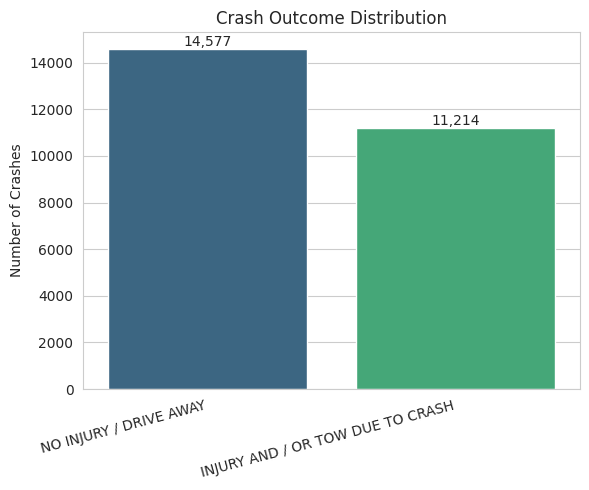

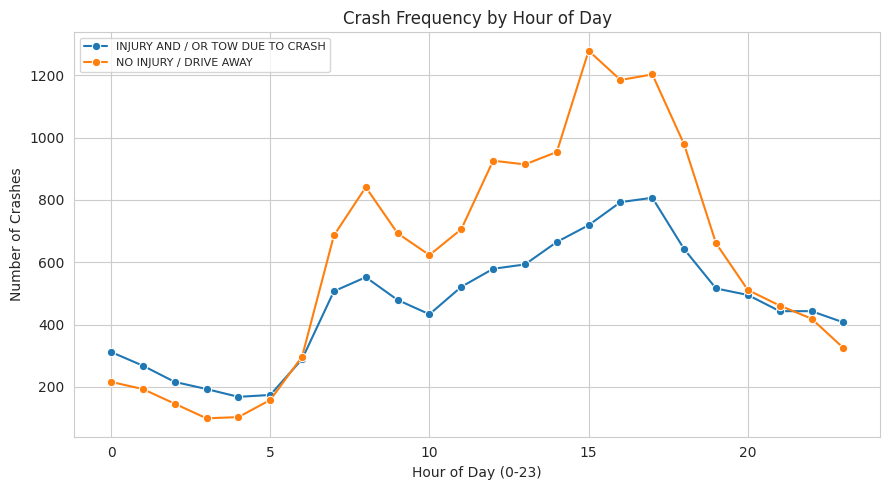

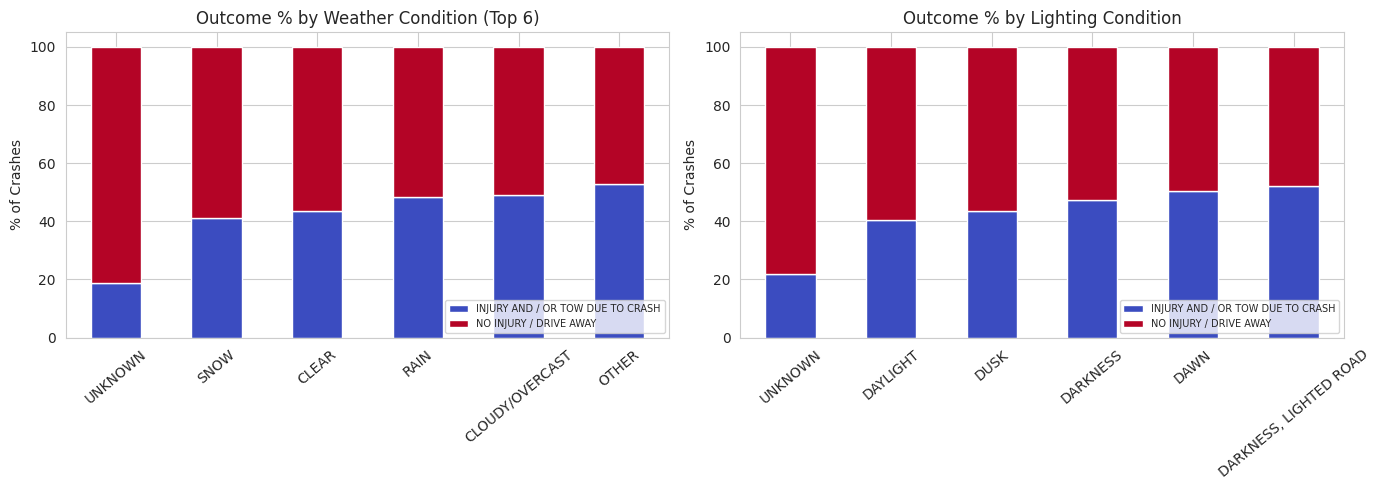

/tmp/ipykernel_2667/2641355420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_fct.index, x=top_fct.values, ax=axes[0], palette="mako")
/tmp/ipykernel_2667/2641355420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cause.index, x=top_cause.values, ax=axes[1], palette="mako")


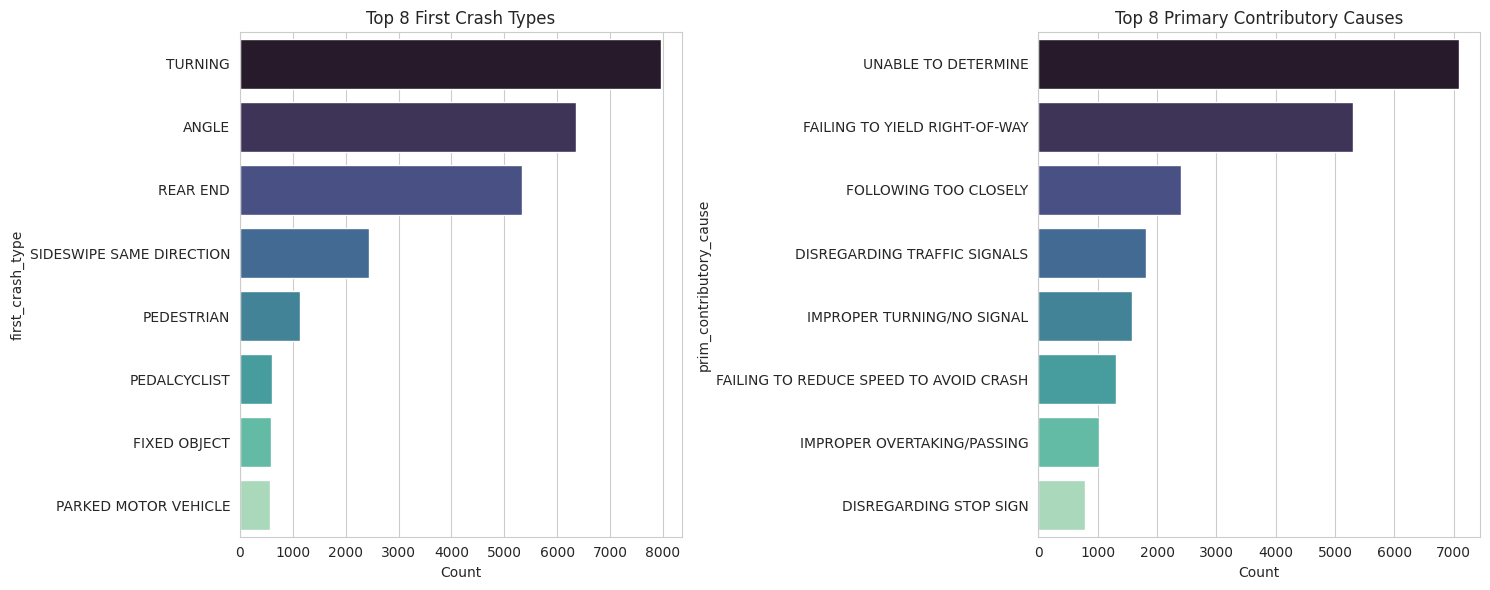

/tmp/ipykernel_2667/1651558066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly.values, palette="crest")


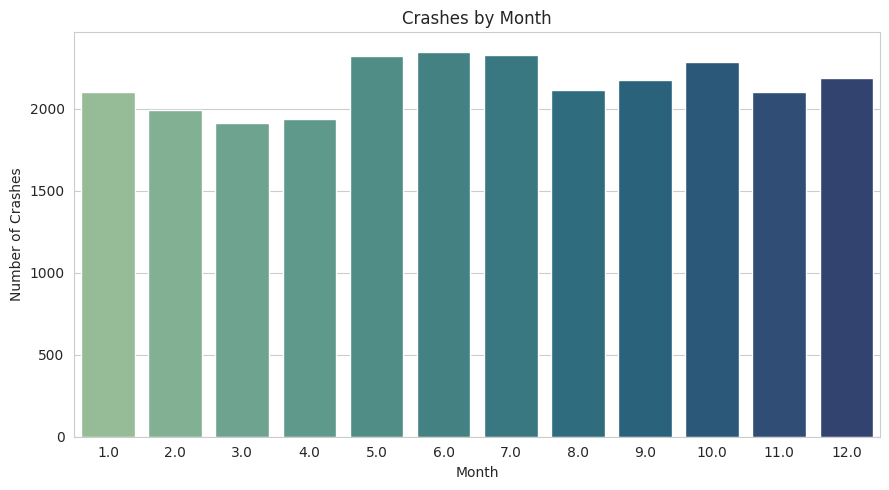

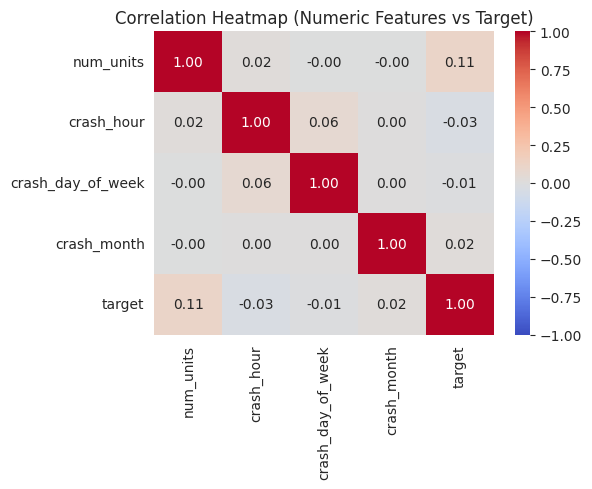

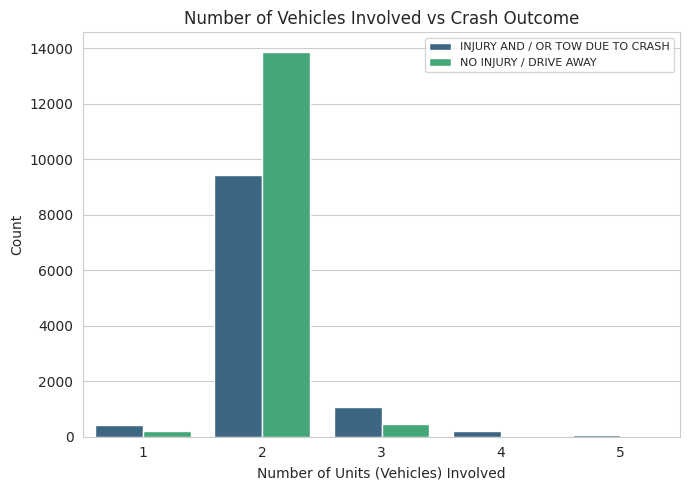

EDA complete. Figures displayed above.

Training Classical Baselines...

--- Logistic Regression ---
  model: Logistic Regression
  accuracy: 0.74
  precision: 0.7158
  recall: 0.6665
  f1: 0.6903
  roc_auc: 0.8115
  fit_time_sec: 1.51
  predict_time_sec: 0.0385

--- Decision Tree ---
  model: Decision Tree
  accuracy: 0.7227
  precision: 0.6803
  recall: 0.6831
  f1: 0.6817
  roc_auc: 0.7855
  fit_time_sec: 0.14
  predict_time_sec: 0.0023

--- Random Forest ---
  model: Random Forest
  accuracy: 0.7395
  precision: 0.6794
  recall: 0.7586
  f1: 0.7169
  roc_auc: 0.8069
  fit_time_sec: 2.52
  predict_time_sec: 0.0697

--- XGBoost ---
  model: XGBoost
  accuracy: 0.7351
  precision: 0.7007
  recall: 0.6819
  f1: 0.6912
  roc_auc: 0.8062
  fit_time_sec: 1.31
  predict_time_sec: 0.0118

Top 5 features by XGBoost importance:
                                  feature  rf_importance  xgb_importance
              first_crash_type_PEDESTRIAN       0.084509        0.111453
                     

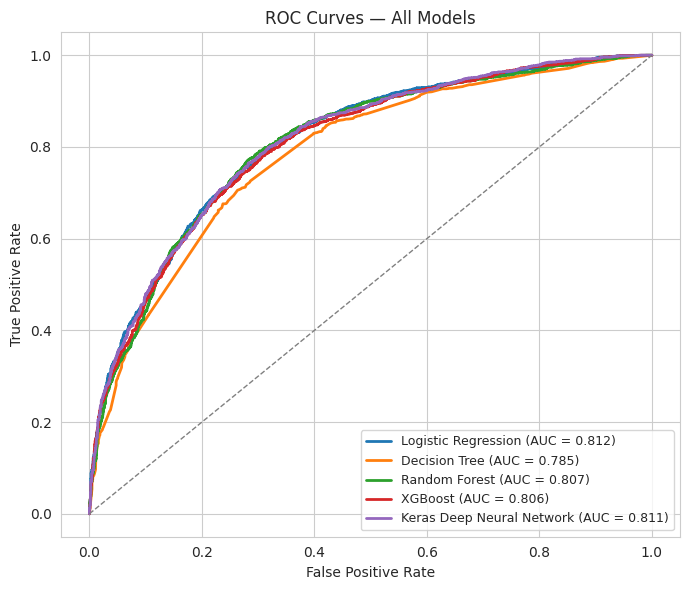


=== FINAL MODEL COMPARISON TABLE ===
                    model  accuracy  precision  recall     f1  roc_auc  fit_time_sec  predict_time_sec
      Logistic Regression    0.7400     0.7158  0.6665 0.6903   0.8115          1.51            0.0385
Keras Deep Neural Network    0.7374     0.6920  0.7134 0.7026   0.8111          7.33            0.2582
            Random Forest    0.7395     0.6794  0.7586 0.7169   0.8069          2.52            0.0697
                  XGBoost    0.7351     0.7007  0.6819 0.6912   0.8062          1.31            0.0118
            Decision Tree    0.7227     0.6803  0.6831 0.6817   0.7855          0.14            0.0023


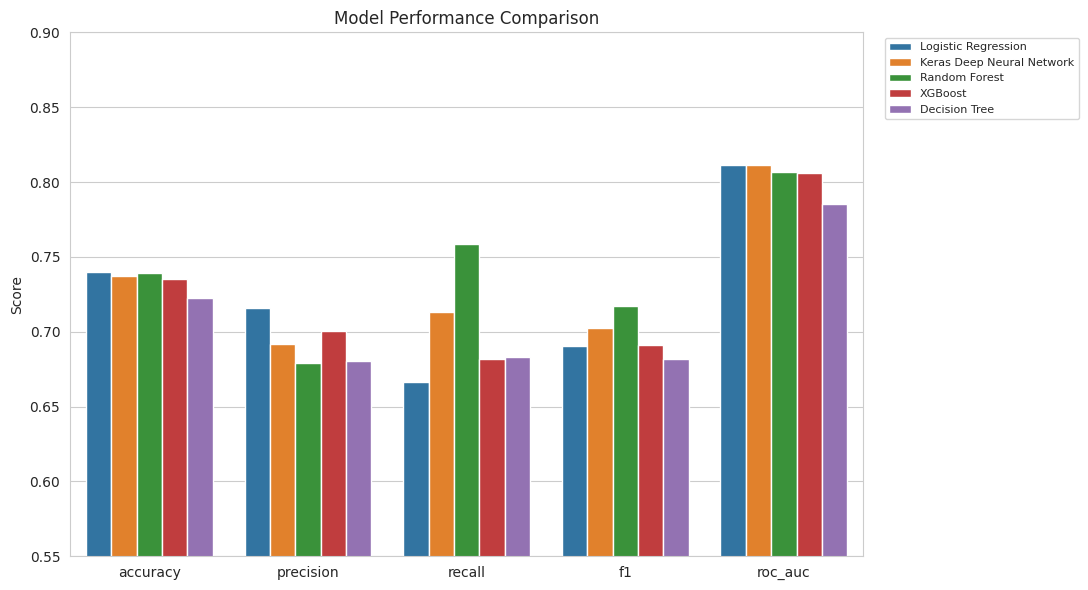

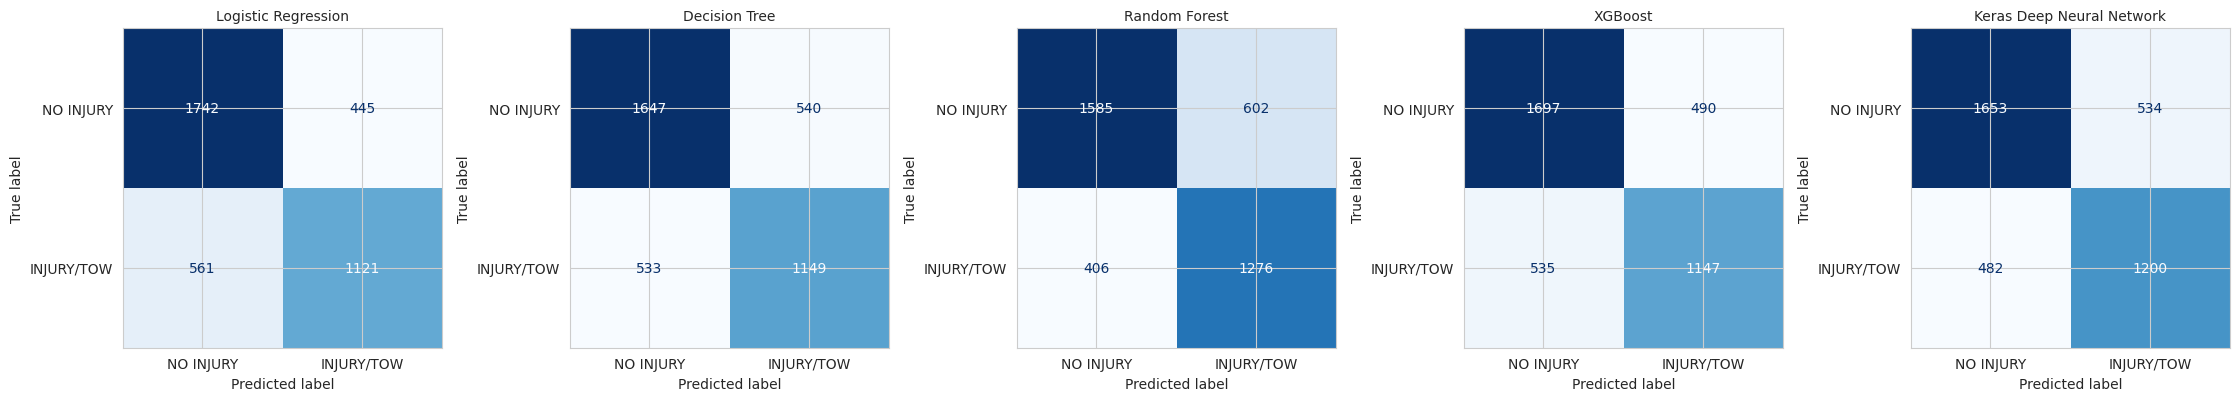


Pipeline finished! All figures have been displayed inline.
Artifacts (CSVs, JSONs, Models, PNGs) have been saved to your Colab workspace root.


In [58]:
if __name__ == "__main__":

    # 1. Load and Clean Data
    print("\nLoading and preprocessing data...")
    raw_df = load_raw()
    model_df = build_modeling_frame(raw_df)

    # 2. Run EDA
    print("\nRunning Exploratory Data Analysis...")
    df_eda = engineer_features(raw_df)
    print_summary(df_eda)
    plot_target_balance(df_eda)
    plot_hourly_pattern(df_eda)
    plot_weather_lighting(df_eda)
    plot_crash_type_and_cause(df_eda)
    plot_monthly_seasonal(df_eda)
    plot_correlation_heatmap(df_eda)
    plot_num_units(df_eda)
    print("EDA complete. Figures displayed above.")

    # 3. Splitting and Encoding
    splits = split_and_encode(model_df)
    X_train, y_train = splits["X_train"], splits["y_train"]
    X_val, y_val = splits["X_val"], splits["y_val"]
    X_test, y_test = splits["X_test"], splits["y_test"]

    # For classical models, combine train + val
    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = np.concatenate([y_train, y_val])

    # 4. Train Baselines
    trained_models, baseline_results = train_baselines(X_train_full, y_train_full, X_test, y_test, splits["feature_names"])

    # 5. Train Deep Learning Model
    print("\nTraining Deep Neural Network...")
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

    # Convert to pure numpy arrays for Keras
    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val
    X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

    best_cfg = architecture_search(X_train_np, y_train, X_val_np, y_val, class_weight_dict)
    dl_model, dl_train_time = train_final_dl_model(best_cfg, X_train_np, y_train, X_val_np, y_val, class_weight_dict)
    dl_metrics = evaluate_dl_model(dl_model, X_test_np, y_test, dl_train_time)

    # Store Keras model inside our running dictionary for ROC plotting
    trained_models["Keras Deep Neural Network"] = ("keras", dl_model)
    all_results = baseline_results + [dl_metrics]

    # 6. Final Eval & Comparison (utilizes models currently kept in memory)
    generate_final_comparisons(trained_models, X_test, y_test, all_results)

    print("\nPipeline finished! All figures have been displayed inline.")
    print("Artifacts (CSVs, JSONs, Models, PNGs) have been saved to your Colab workspace root.")